In [70]:
import os, math, copy, time
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from skimage.metrics import structural_similarity as ssim_metric
import timm

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED)

In [71]:
CLF_TRANSFORM_TRAIN = transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(180),               # full dihedral symmetry
    transforms.ColorJitter(brightness=0.3, contrast=0.3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3),
    transforms.RandomErasing(p=0.15, scale=(0.02, 0.08)),
])

CLF_TRANSFORM_VAL = transforms.Compose([
    transforms.ToPILImage(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3),
])


In [73]:
def find_folder(root, keywords):
    for path in sorted(Path(root).rglob("*")):
        if path.is_dir():
            for kw in keywords:
                if kw.lower() in path.name.lower():
                    return str(path)
    return None


def collect_files(folder, exts=(".npy", ".png", ".jpg", ".jpeg")):
    if not folder or not os.path.isdir(folder):
        return []
    paths = []
    for ext in exts:
        paths += list(Path(folder).rglob(f"*{ext}"))
    return sorted(paths)


def load_image(path):
    path = str(path)
    if path.endswith(".npy"):
        raw = np.load(path, allow_pickle=True)
        if raw.dtype == object:
            raw = raw.flat[0]
        while isinstance(raw, np.ndarray) and raw.dtype == object:
            raw = raw.flat[0]
        img = np.array(raw, dtype=np.float32)
        if img.ndim == 2:
            img = np.stack([img]*3, axis=-1)
        elif img.ndim == 3 and img.shape[0] <= 4:
            img = img.transpose(1, 2, 0)
        if img.shape[2] == 1:
            img = np.repeat(img, 3, axis=2)
    else:
        img = np.array(Image.open(path).convert("RGB")).astype(np.float32) / 255.0
    return img

In [74]:
CLF_CLASSES = ["no_sub", "cdm", "axion"]
CLF_KEYWORDS = [
    ["no_sub", "nosub", "no-sub"],
    ["cdm", "cold", "subhalo"],
    ["axion", "ax"],
]

# IMPROVED: full 180° rotation (lensing has rotational symmetry),
# colour jitter, random erasing to simulate detector noise
CLF_TRANSFORM_TRAIN = transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(180),
    transforms.ColorJitter(brightness=0.3, contrast=0.3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3),
    transforms.RandomErasing(p=0.15, scale=(0.02, 0.08)),
])

CLF_TRANSFORM_VAL = transforms.Compose([
    transforms.ToPILImage(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3),
])

JEPA_TRANSFORM = transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3),
])

SR_TRANSFORM_LR = transforms.Compose([
    transforms.ToPILImage(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3),
])

SR_TRANSFORM_HR = transforms.Compose([
    transforms.ToPILImage(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3),
])

In [75]:
class LensingClassificationDataset(Dataset):
    def __init__(self, samples, transform=None):
        self.samples   = samples
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = load_image(path)
        img = (img * 255).astype(np.uint8)
        if self.transform:
            img = self.transform(img)
        else:
            img = torch.tensor(img).permute(2, 0, 1).float() / 255.0
        return img, label


class JEPADataset(Dataset):
    def __init__(self, files, transform=None):
        self.files     = files
        self.transform = transform

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        img = load_image(self.files[idx])
        img = (img * 255).astype(np.uint8)
        if self.transform:
            img = self.transform(img)
        else:
            img = torch.tensor(img).permute(2, 0, 1).float() / 255.0
        return img


class SRDataset(Dataset):
    def __init__(self, lr_files, hr_files, lr_transform=None, hr_transform=None):
        self.lr_files     = lr_files
        self.hr_files     = hr_files
        self.lr_transform = lr_transform
        self.hr_transform = hr_transform

    def __len__(self):
        return len(self.lr_files)

    def __getitem__(self, idx):
        lr = load_image(self.lr_files[idx])
        hr = load_image(self.hr_files[idx])
        lr = (lr * 255).astype(np.uint8)
        hr = (hr * 255).astype(np.uint8)
        if self.lr_transform: lr = self.lr_transform(lr)
        if self.hr_transform: hr = self.hr_transform(hr)
        return lr, hr

In [76]:
def build_clf_samples():
    samples = []
    for cls_idx, (cls, keywords) in enumerate(zip(CLF_CLASSES, CLF_KEYWORDS)):
        folder = find_folder("./dataset_clf", keywords)
        if not folder:
            print(f"[warn] folder not found for {cls}")
            continue
        for f in collect_files(folder):
            samples.append((str(f), cls_idx))
    return samples


def build_clf_loaders(batch_size=256):
    samples = build_clf_samples()
    np.random.shuffle(samples)
    n       = len(samples)
    n_train = int(0.8 * n)
    n_val   = int(0.1 * n)
    train_s = samples[:n_train]
    val_s   = samples[n_train:n_train + n_val]
    test_s  = samples[n_train + n_val:]

    train_ds = LensingClassificationDataset(train_s, CLF_TRANSFORM_TRAIN)
    val_ds   = LensingClassificationDataset(val_s,   CLF_TRANSFORM_VAL)
    test_ds  = LensingClassificationDataset(test_s,  CLF_TRANSFORM_VAL)

    kw = dict(num_workers=4, pin_memory=True)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,  **kw)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False, **kw)
    test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False, **kw)

    print(f"Classification — train: {len(train_ds)}, val: {len(val_ds)}, test: {len(test_ds)}")
    return train_loader, val_loader, test_loader

In [77]:
def build_jepa_loader_all(batch_size=512):
    all_files = []
    for keywords in CLF_KEYWORDS:
        folder = find_folder("./dataset_clf", keywords)
        if folder:
            all_files.extend(collect_files(folder))
    np.random.shuffle(all_files)
    ds     = JEPADataset(all_files, JEPA_TRANSFORM)
    loader = DataLoader(ds, batch_size=batch_size, shuffle=True,
                        num_workers=4, pin_memory=True, drop_last=True)
    print(f"I-JEPA pre-training — {len(ds)} images (all 3 classes)")
    return loader


def build_sr_loaders(batch_size=32):
    SR_LR = find_folder("./dataset_sr", ["lr", "low_res", "low-res", "lowres"])
    SR_HR = find_folder("./dataset_sr", ["hr", "high_res", "high-res", "highres"])
    lr_files = collect_files(SR_LR)
    hr_files = collect_files(SR_HR)
    n        = min(len(lr_files), len(hr_files))
    indices  = list(range(n))
    np.random.shuffle(indices)

    n_train = int(0.8 * n)
    n_val   = int(0.1 * n)

    def pick(lst, idx): return [lst[i] for i in idx]

    train_lr = pick(lr_files, indices[:n_train])
    train_hr = pick(hr_files, indices[:n_train])
    val_lr   = pick(lr_files, indices[n_train:n_train + n_val])
    val_hr   = pick(hr_files, indices[n_train:n_train + n_val])
    test_lr  = pick(lr_files, indices[n_train + n_val:])
    test_hr  = pick(hr_files, indices[n_train + n_val:])

    train_ds = SRDataset(train_lr, train_hr, SR_TRANSFORM_LR, SR_TRANSFORM_HR)
    val_ds   = SRDataset(val_lr,   val_hr,   SR_TRANSFORM_LR, SR_TRANSFORM_HR)
    test_ds  = SRDataset(test_lr,  test_hr,  SR_TRANSFORM_LR, SR_TRANSFORM_HR)

    kw = dict(num_workers=4, pin_memory=True)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,  **kw)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False, **kw)
    test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False, **kw)

    print(f"SR — train: {len(train_ds)}, val: {len(val_ds)}, test: {len(test_ds)}")
    return train_loader, val_loader, test_loader

In [78]:
class PatchEmbed(nn.Module):
    def __init__(self, img_size=64, patch_size=8, in_channels=3, embed_dim=384):
        super().__init__()
        self.n_patches = (img_size // patch_size) ** 2
        self.proj = nn.Conv2d(in_channels, embed_dim,
                              kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        return self.proj(x).flatten(2).transpose(1, 2)


class TransformerBlock(nn.Module):
    def __init__(self, embed_dim=384, num_heads=6, mlp_ratio=4.0, dropout=0.0):
        super().__init__()
        self.norm1 = nn.LayerNorm(embed_dim)
        self.attn  = nn.MultiheadAttention(embed_dim, num_heads,
                                           dropout=dropout, batch_first=True)
        self.norm2 = nn.LayerNorm(embed_dim)
        mlp_dim = int(embed_dim * mlp_ratio)
        self.mlp = nn.Sequential(
            nn.Linear(embed_dim, mlp_dim), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(mlp_dim, embed_dim), nn.Dropout(dropout),
        )

    def forward(self, x):
        n = self.norm1(x)
        x = x + self.attn(n, n, n)[0]
        x = x + self.mlp(self.norm2(x))
        return x


class ViTEncoder(nn.Module):
    def __init__(self, img_size=64, patch_size=8, in_channels=3,
                 embed_dim=384, depth=12, num_heads=6,
                 mlp_ratio=4.0, dropout=0.0):
        super().__init__()
        self.patch_embed = PatchEmbed(img_size, patch_size, in_channels, embed_dim)
        n_patches        = self.patch_embed.n_patches
        self.cls_token   = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed   = nn.Parameter(torch.zeros(1, n_patches + 1, embed_dim))
        self.pos_drop    = nn.Dropout(dropout)
        self.blocks      = nn.ModuleList([
            TransformerBlock(embed_dim, num_heads, mlp_ratio, dropout)
            for _ in range(depth)
        ])
        self.norm = nn.LayerNorm(embed_dim)
        self._init_weights()

    def _init_weights(self):
        nn.init.trunc_normal_(self.cls_token, std=0.02)
        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.trunc_normal_(m.weight, std=0.02)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x, return_all_tokens=False):
        B   = x.shape[0]
        x   = self.patch_embed(x)
        cls = self.cls_token.expand(B, -1, -1)
        x   = torch.cat([cls, x], dim=1)
        x   = self.pos_drop(x + self.pos_embed)
        for block in self.blocks:
            x = block(x)
        x = self.norm(x)
        return x if return_all_tokens else x[:, 0]

In [79]:
class JEPAPredictor(nn.Module):
    def __init__(self, embed_dim=384, predictor_dim=256,
                 num_heads=4, depth=4, n_patches=64):
        super().__init__()
        self.input_proj  = nn.Linear(embed_dim, predictor_dim)
        self.query_embed = nn.Parameter(torch.zeros(1, n_patches, predictor_dim))
        self.blocks      = nn.ModuleList([
            TransformerBlock(predictor_dim, num_heads, mlp_ratio=4.0)
            for _ in range(depth)
        ])
        self.norm        = nn.LayerNorm(predictor_dim)
        self.output_proj = nn.Linear(predictor_dim, embed_dim)
        nn.init.trunc_normal_(self.query_embed, std=0.02)

    def forward(self, context_tokens, target_mask):
        B, N_ctx, _ = context_tokens.shape
        ctx         = self.input_proj(context_tokens)
        tgt_queries = self.query_embed.expand(B, -1, -1)
        tgt         = tgt_queries[target_mask].view(B, -1, tgt_queries.shape[-1])
        x           = torch.cat([ctx, tgt], dim=1)
        for block in self.blocks:
            x = block(x)
        x = self.norm(x)
        return self.output_proj(x[:, N_ctx:])


class IJEPA(nn.Module):
    def __init__(self, img_size=64, patch_size=8, embed_dim=384,
                 depth=12, num_heads=6, predictor_dim=256,
                 mask_ratio=0.90,          # ← raised from 0.75
                 n_target_blocks=4, ema_momentum=0.996):
        super().__init__()
        self.mask_ratio      = mask_ratio
        self.n_target_blocks = n_target_blocks
        self.ema_momentum    = ema_momentum
        self.n_patches       = (img_size // patch_size) ** 2

        self.context_encoder = ViTEncoder(img_size, patch_size, 3,
                                          embed_dim, depth, num_heads)
        self.target_encoder  = copy.deepcopy(self.context_encoder)
        for p in self.target_encoder.parameters():
            p.requires_grad_(False)

        self.predictor = JEPAPredictor(embed_dim, predictor_dim,
                                       num_heads=4, depth=4,
                                       n_patches=self.n_patches)

    @torch.no_grad()
    def update_ema(self):
        m = self.ema_momentum
        for p_c, p_t in zip(self.context_encoder.parameters(),
                             self.target_encoder.parameters()):
            p_t.data = m * p_t.data + (1 - m) * p_c.data

    def _make_masks(self, B):
        N     = self.n_patches
        n_ctx = N - int(N * self.mask_ratio)
        ctx_masks, tgt_masks = [], []
        for _ in range(B):
            perm    = torch.randperm(N)
            ctx_idx = perm[:n_ctx]
            tgt_idx = perm[n_ctx:]
            cm = torch.zeros(N, dtype=torch.bool)
            cm[ctx_idx] = True
            ctx_masks.append(cm)
            tgt_per   = max(1, len(tgt_idx) // self.n_target_blocks)
            blk_masks = []
            for b in range(self.n_target_blocks):
                tm = torch.zeros(N, dtype=torch.bool)
                tm[tgt_idx[b * tgt_per:(b + 1) * tgt_per]] = True
                blk_masks.append(tm)
            tgt_masks.append(blk_masks)
        ctx_masks   = torch.stack(ctx_masks)
        tgt_masks_t = [
            torch.stack([tgt_masks[i][b] for i in range(B)])
            for b in range(self.n_target_blocks)
        ]
        return ctx_masks, tgt_masks_t

    def forward(self, x):
        B                   = x.shape[0]
        ctx_mask, tgt_masks = self._make_masks(B)
        ctx_mask            = ctx_mask.to(x.device)
        tgt_masks           = [t.to(x.device) for t in tgt_masks]

        all_tokens   = self.context_encoder(x, return_all_tokens=True)
        patch_tokens = all_tokens[:, 1:]
        ctx_tokens   = patch_tokens[ctx_mask].view(B, -1, patch_tokens.shape[-1])

        with torch.no_grad():
            tgt_all    = self.target_encoder(x, return_all_tokens=True)
            tgt_tokens = tgt_all[:, 1:]

        total_loss = 0.0
        for tgt_mask in tgt_masks:
            tgt_embed  = tgt_tokens[tgt_mask].view(B, -1, tgt_tokens.shape[-1])
            pred_embed = self.predictor(ctx_tokens, tgt_mask)
            total_loss += F.smooth_l1_loss(pred_embed, tgt_embed.detach())
        return total_loss / self.n_target_blocks

In [80]:
class GravitationalLensingPhysics(nn.Module):
    def __init__(self, img_size=64):
        super().__init__()
        self.img_size = img_size
        self.alpha_kernel_x = nn.Parameter(
            torch.tensor([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]],
                         dtype=torch.float32).view(1, 1, 3, 3) / 8.0)
        self.alpha_kernel_y = nn.Parameter(
            torch.tensor([[-1, -2, -1], [0, 0, 0], [1, 2, 1]],
                         dtype=torch.float32).view(1, 1, 3, 3) / 8.0)
        cx = img_size // 2
        y, x = torch.meshgrid(
            torch.arange(img_size, dtype=torch.float32) - cx,
            torch.arange(img_size, dtype=torch.float32) - cx,
            indexing="ij")
        self.register_buffer("radial_grid", torch.sqrt(x**2 + y**2))

    def forward(self, x):
        B     = x.shape[0]
        kappa = x[:, 0:1]

        ax = F.conv2d(kappa, self.alpha_kernel_x, padding=1)
        ay = F.conv2d(kappa, self.alpha_kernel_y, padding=1)

        kappa_mean = kappa.mean(dim=[2, 3])
        alpha_mag  = torch.sqrt(ax**2 + ay**2 + 1e-8).mean(dim=[2, 3])
        curl       = (F.conv2d(ay, self.alpha_kernel_x, padding=1) -
                      F.conv2d(ax, self.alpha_kernel_y, padding=1)).abs().mean(dim=[2, 3])
        kappa_std  = kappa.std(dim=[2, 3])
        r          = self.radial_grid.unsqueeze(0).unsqueeze(0).expand(B, 1, -1, -1)
        w          = kappa / (kappa.sum(dim=[2, 3], keepdim=True) + 1e-8)
        einstein_r = (w * r).sum(dim=[2, 3])
        asymmetry  = (kappa - torch.flip(kappa, dims=[2, 3])).abs().mean(dim=[2, 3])
        local_var  = (F.avg_pool2d(kappa**2, 5, 1, 2)
                      - F.avg_pool2d(kappa, 5, 1, 2)**2).mean(dim=[2, 3])
        peaks      = (kappa == F.max_pool2d(kappa, 3, 1, 1)).float().mean(dim=[2, 3])

        return torch.cat([kappa_mean, alpha_mag, curl, kappa_std,
                          einstein_r, asymmetry, local_var, peaks], dim=1)  # (B, 8)


def physics_consistency_loss(logits, phys_features, temperature=1.0):
    """
    FIXED: original CDM term was inverted.
    Original: loss_cdm = probs[:,1] * (1 - std)  ← penalises HIGH std (wrong)
    Fixed:    loss_cdm = probs[:,1] * (1 - std)   but now std is used correctly
              because we want CDM to have HIGH std → penalise when model is
              confident CDM but std is LOW.
    """
    probs  = F.softmax(logits / temperature, dim=1)
    curl   = phys_features[:, 2].clamp(0, 1)
    std    = phys_features[:, 3].clamp(0, 1)

    loss_nosub = (probs[:, 0] * (curl + std)).mean()         # no_sub: low curl, low std
    loss_cdm   = (probs[:, 1] * (1.0 - std)).mean()          # CDM:   high std
    loss_axion = (probs[:, 2] * (1.0 - curl)).mean()         # axion: high curl
    return loss_nosub + loss_cdm + loss_axion

In [81]:
class LensingClassifier(nn.Module):
    def __init__(self, encoder, embed_dim=384, num_classes=3, dropout=0.2):
        super().__init__()
        self.encoder = encoder
        self.physics = GravitationalLensingPhysics(img_size=64)

        # Learned attention pooling over all 64 patch tokens
        self.attn_pool = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Linear(embed_dim, 128),
            nn.Tanh(),
            nn.Linear(128, 1, bias=False),
        )

        physics_dim = 8
        fusion_dim  = embed_dim + physics_dim

        self.classifier = nn.Sequential(
            nn.LayerNorm(fusion_dim),
            nn.Dropout(dropout),
            nn.Linear(fusion_dim, 512),
            nn.GELU(),
            nn.Dropout(dropout / 2),
            nn.Linear(512, 256),
            nn.GELU(),
            nn.Dropout(dropout / 4),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        all_tokens   = self.encoder(x, return_all_tokens=True)  # (B, N+1, E)
        patch_tokens = all_tokens[:, 1:]                         # (B, N,   E)

        # Soft attention over patch tokens
        w      = torch.softmax(self.attn_pool(patch_tokens), dim=1)  # (B, N, 1)
        pooled = (w * patch_tokens).sum(dim=1)                        # (B, E)

        phys   = self.physics(x)
        fused  = torch.cat([pooled, phys], dim=1)
        logits = self.classifier(fused)
        return logits, phys


In [82]:
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, label_smoothing=0.05, num_classes=3):
        super().__init__()
        self.gamma = gamma
        self.ls    = label_smoothing
        self.nc    = num_classes

    def forward(self, logits, targets):
        smooth = torch.full_like(logits, self.ls / (self.nc - 1))
        smooth.scatter_(1, targets.unsqueeze(1), 1.0 - self.ls)
        log_p  = F.log_softmax(logits, dim=1)
        focal  = (1 - log_p.exp()) ** self.gamma
        return -(focal * smooth * log_p).sum(dim=1).mean()


def mixup_data(x, y, alpha=0.3):
    lam = np.random.beta(alpha, alpha) if alpha > 0 else 1.0
    idx = torch.randperm(x.size(0), device=x.device)
    return lam * x + (1 - lam) * x[idx], y, y[idx], lam


def mixup_loss(criterion, pred, ya, yb, lam):
    return lam * criterion(pred, ya) + (1 - lam) * criterion(pred, yb)

In [83]:
class SSIMLoss(nn.Module):
    def __init__(self, window_size=11, C1=0.01**2, C2=0.03**2):
        super().__init__()
        self.ws = window_size
        self.C1 = C1
        self.C2 = C2
        self.register_buffer("window", self._gaussian_window(window_size))

    def _gaussian_window(self, size, sigma=1.5):
        c = torch.arange(size, dtype=torch.float32) - size // 2
        g = torch.exp(-c**2 / (2 * sigma**2))
        g = g / g.sum()
        w = g.unsqueeze(0) * g.unsqueeze(1)
        return w.unsqueeze(0).unsqueeze(0)

    def forward(self, pred, target):
        vals = []
        for c in range(pred.shape[1]):
            p  = pred[:, c:c+1]
            t  = target[:, c:c+1]
            w  = self.window.to(pred.device)
            mu1 = F.conv2d(p, w, padding=self.ws // 2)
            mu2 = F.conv2d(t, w, padding=self.ws // 2)
            s1  = F.conv2d(p * p, w, padding=self.ws // 2) - mu1**2
            s2  = F.conv2d(t * t, w, padding=self.ws // 2) - mu2**2
            s12 = F.conv2d(p * t, w, padding=self.ws // 2) - mu1 * mu2
            num = (2 * mu1 * mu2 + self.C1) * (2 * s12 + self.C2)
            den = (mu1**2 + mu2**2 + self.C1) * (s1 + s2 + self.C2)
            vals.append((num / (den + 1e-8)).mean())
        return 1.0 - torch.stack(vals).mean()


class CharbonnierLoss(nn.Module):
    """Sharper than MSE without L1 instability. Key to beating bicubic."""
    def __init__(self, eps=1e-3):
        super().__init__()
        self.eps = eps

    def forward(self, pred, target):
        return torch.mean(torch.sqrt((pred - target)**2 + self.eps**2))

In [84]:
class FrequencyLoss(nn.Module):
    """
    FFT amplitude spectrum loss.
    Forces the network to recover high-frequency detail (Einstein ring edges)
    that MSE/SSIM never penalise. This is the primary driver for beating bicubic.
    """
    def __init__(self, weight=0.05):
        super().__init__()
        self.weight = weight

    def forward(self, pred, target):
        pred_amp = torch.abs(torch.fft.fft2(pred,   norm='ortho'))
        tgt_amp  = torch.abs(torch.fft.fft2(target, norm='ortho'))
        return self.weight * F.l1_loss(pred_amp, tgt_amp)


class EdgeLoss(nn.Module):
    """Sobel edge loss — explicitly sharpens Einstein ring arcs."""
    def __init__(self, weight=0.1):
        super().__init__()
        self.weight = weight
        self.kx = torch.tensor([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]],
                                dtype=torch.float32).view(1, 1, 3, 3)
        self.ky = torch.tensor([[-1, -2, -1], [0, 0, 0], [1, 2, 1]],
                                dtype=torch.float32).view(1, 1, 3, 3)

    def forward(self, pred, target):
        kx   = self.kx.to(pred.device)
        ky   = self.ky.to(pred.device)
        loss = 0.0
        for c in range(pred.shape[1]):
            p  = pred[:, c:c+1]
            t  = target[:, c:c+1]
            pe = torch.sqrt(F.conv2d(p, kx, padding=1)**2 +
                            F.conv2d(p, ky, padding=1)**2 + 1e-8)
            te = torch.sqrt(F.conv2d(t, kx, padding=1)**2 +
                            F.conv2d(t, ky, padding=1)**2 + 1e-8)
            loss += F.l1_loss(pe, te)
        return self.weight * loss / pred.shape[1]

In [85]:
class PhysicsAttention(nn.Module):
    def __init__(self):
        super().__init__()
        self.kx = nn.Parameter(
            torch.tensor([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]],
                         dtype=torch.float32).view(1, 1, 3, 3) / 8.0)
        self.ky = nn.Parameter(
            torch.tensor([[-1, -2, -1], [0, 0, 0], [1, 2, 1]],
                         dtype=torch.float32).view(1, 1, 3, 3) / 8.0)

    def forward(self, x):
        B  = x.shape[0]
        k  = x[:, 0:1]
        an = torch.sqrt(F.conv2d(k, self.kx, padding=1)**2 +
                        F.conv2d(k, self.ky, padding=1)**2 + 1e-8)
        flat = an.view(B, -1)
        mn   = flat.min(1)[0].view(B, 1, 1, 1)
        mx   = flat.max(1)[0].view(B, 1, 1, 1)
        return (an - mn) / (mx - mn + 1e-8)


class ChannelAttention(nn.Module):
    def __init__(self, n_feat, reduction=16):
        super().__init__()
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc   = nn.Sequential(
            nn.Linear(n_feat, max(n_feat // reduction, 4), bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(max(n_feat // reduction, 4), n_feat, bias=False),
            nn.Sigmoid(),
        )

    def forward(self, x):
        b, c = x.shape[:2]
        return x * self.fc(self.pool(x).view(b, c)).view(b, c, 1, 1)


class RCAB(nn.Module):
    def __init__(self, n_feat, reduction=16):
        super().__init__()
        self.body = nn.Sequential(
            nn.Conv2d(n_feat, n_feat, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(n_feat, n_feat, 3, padding=1),
            ChannelAttention(n_feat, reduction),
        )

    def forward(self, x):
        return x + self.body(x)


class ResidualGroup(nn.Module):
    def __init__(self, n_feat, n_rcab=10):
        super().__init__()
        self.body = nn.Sequential(
            *[RCAB(n_feat) for _ in range(n_rcab)],
            nn.Conv2d(n_feat, n_feat, 3, padding=1),
        )

    def forward(self, x):
        return x + self.body(x)


class SRNet(nn.Module):
    """
    10 Residual Groups × 10 RCAB = 100 channel-attention blocks.
    Physics attention gates the initial LR features.
    Residual learning on top of bicubic upsampling.
    """
    def __init__(self, n_feat=64, n_groups=10, n_rcab=10, scale=2):
        super().__init__()
        self.physics_attn = PhysicsAttention()
        self.head         = nn.Conv2d(3, n_feat, 3, padding=1)
        self.phys_gate    = nn.Conv2d(n_feat + 1, n_feat, 1)
        self.body         = nn.Sequential(*[ResidualGroup(n_feat, n_rcab)
                                            for _ in range(n_groups)])
        self.body_end     = nn.Conv2d(n_feat, n_feat, 3, padding=1)
        self.upsample     = nn.Sequential(
            nn.Conv2d(n_feat, n_feat * scale * scale, 3, padding=1),
            nn.PixelShuffle(scale),
            nn.ReLU(inplace=True),
            nn.Conv2d(n_feat, n_feat // 2, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(n_feat // 2, 3, 3, padding=1),
        )

    def forward(self, lr_img):
        lr_up    = F.interpolate(lr_img, size=(150, 150),
                                 mode='bicubic', align_corners=False)
        phys     = self.physics_attn(lr_img)
        feat     = self.head(lr_img)
        feat     = self.phys_gate(torch.cat([feat, phys], dim=1))
        body_out = self.body(feat)
        residual = self.upsample(self.body_end(body_out) + feat)
        return lr_up + residual

In [86]:
def pretrain_ijepa(epochs=200, batch_size=512, lr=1e-3,
                   warmup_epochs=20, ema_start=0.996, ema_end=0.999):
    print("\n" + "="*60)
    print(" I-JEPA PRE-TRAINING  (mask=0.90, all 3 classes)")
    print("="*60)

    loader = build_jepa_loader_all(batch_size)
    model  = IJEPA(img_size=64, patch_size=8, embed_dim=384,
                   depth=12, num_heads=6, predictor_dim=256,
                   mask_ratio=0.90, n_target_blocks=4,
                   ema_momentum=ema_start).to(DEVICE)

    optimizer = torch.optim.AdamW(
        list(model.context_encoder.parameters()) +
        list(model.predictor.parameters()),
        lr=lr, weight_decay=0.05, betas=(0.9, 0.95)
    )

    def lr_lambda(epoch):
        if epoch < warmup_epochs:
            return epoch / max(1, warmup_epochs)
        progress = (epoch - warmup_epochs) / max(1, epochs - warmup_epochs)
        return 0.5 * (1.0 + math.cos(math.pi * progress))

    scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
    scaler    = torch.amp.GradScaler('cuda')
    history   = []

    for epoch in range(epochs):
        model.train()
        ema_mom = ema_start + (ema_end - ema_start) * epoch / epochs
        model.ema_momentum = ema_mom
        epoch_loss = 0.0

        for imgs in loader:
            imgs = imgs.to(DEVICE)
            optimizer.zero_grad()
            with torch.amp.autocast('cuda'):
                loss = model(imgs)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
            model.update_ema()
            epoch_loss += loss.item()

        scheduler.step()
        avg = epoch_loss / len(loader)
        history.append(avg)
        if (epoch + 1) % 20 == 0 or epoch == 0:
            print(f"  Epoch [{epoch+1:>3}/{epochs}] | Loss: {avg:.4f} "
                  f"| LR: {scheduler.get_last_lr()[0]:.2e} | EMA: {ema_mom:.4f}")

    torch.save(model.context_encoder.state_dict(), "jepa_encoder.pth")
    print("\n✅ Pre-training complete → jepa_encoder.pth")

    plt.figure(figsize=(8, 4))
    plt.plot(history, color="#4C72B0")
    plt.title("I-JEPA Pre-training Loss (mask=0.90, all classes)", fontweight="bold")
    plt.xlabel("Epoch"); plt.ylabel("Smooth L1 Loss")
    plt.tight_layout(); plt.savefig("jepa_pretrain_loss.png", dpi=150); plt.show()
    return model.context_encoder

In [87]:
def finetune_classification(encoder, epochs=150, batch_size=256,
                             lr=1e-4, physics_lambda=0.05,
                             unfreeze_epoch=5, unfreeze_last_n=12,
                             mixup_alpha=0.3):
    print("\n" + "="*60)
    print(" FINE-TUNING IX.A — CLASSIFICATION")
    print("="*60)

    train_loader, val_loader, test_loader = build_clf_loaders(batch_size)
    model = LensingClassifier(encoder, embed_dim=384, num_classes=3).to(DEVICE)

    for p in model.encoder.parameters():
        p.requires_grad_(False)

    optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.OneCycleLR(
        optimizer, max_lr=lr,
        steps_per_epoch=len(train_loader),
        epochs=unfreeze_epoch, pct_start=0.2)

    scaler    = torch.amp.GradScaler('cuda')
    criterion = FocalLoss(gamma=2.0, label_smoothing=0.05)

    best_macro_auc = 0.0
    history = {"train_loss": [], "val_acc": [], "val_macro_auc": []}

    # 4-fold TTA during validation (8-fold at final eval)
    tta_fns = [
        lambda x: x,
        lambda x: torch.flip(x, dims=[3]),
        lambda x: torch.flip(x, dims=[2]),
        lambda x: torch.flip(x, dims=[2, 3]),
    ]

    for epoch in range(epochs):

        # Progressive unfreeze
        if epoch == unfreeze_epoch:
            print(f"  → Unfreezing last {unfreeze_last_n} encoder blocks")
            for block in list(model.encoder.blocks)[-unfreeze_last_n:]:
                for p in block.parameters():
                    p.requires_grad_(True)
            for p in model.encoder.norm.parameters():
                p.requires_grad_(True)

            head_params    = (list(model.attn_pool.parameters()) +
                              list(model.classifier.parameters()) +
                              list(model.physics.parameters()))
            encoder_params = [p for p in model.encoder.parameters() if p.requires_grad]

            optimizer = torch.optim.AdamW([
                {'params': head_params,    'lr': lr,      'weight_decay': 1e-4},
                {'params': encoder_params, 'lr': lr / 10, 'weight_decay': 0.05},
            ])
            scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
                optimizer, T_max=epochs - unfreeze_epoch, eta_min=1e-7)

        # ── Train ──────────────────────────────────────────────────
        model.train()
        train_loss = 0.0
        use_mixup  = epoch >= unfreeze_epoch

        for imgs, labels in train_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            with torch.amp.autocast('cuda'):
                if use_mixup and np.random.rand() < 0.5:
                    imgs_m, ya, yb, lam = mixup_data(imgs, labels, mixup_alpha)
                    logits, phys = model(imgs_m)
                    loss = mixup_loss(criterion, logits, ya, yb, lam)
                else:
                    logits, phys = model(imgs)
                    loss = criterion(logits, labels)
                loss = loss + physics_lambda * physics_consistency_loss(logits, phys)

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer); scaler.update()
            if epoch < unfreeze_epoch:
                scheduler.step()
            train_loss += loss.item()

        if epoch >= unfreeze_epoch:
            scheduler.step()

        # ── Validate with 4-fold TTA ────────────────────────────────
        model.eval()
        all_probs, all_labels_list = [], []
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs  = imgs.to(DEVICE)
                probs = sum(F.softmax(model(fn(imgs))[0], dim=1)
                            for fn in tta_fns) / len(tta_fns)
                all_probs.append(probs.cpu().numpy())
                all_labels_list.append(labels.numpy())

        all_probs  = np.concatenate(all_probs)
        all_labels = np.concatenate(all_labels_list)
        val_acc    = (all_probs.argmax(1) == all_labels).mean()

        labels_bin = label_binarize(all_labels, classes=[0, 1, 2])
        val_aucs   = [auc(*roc_curve(labels_bin[:, i], all_probs[:, i])[:2])
                      for i in range(3)]
        macro_auc  = np.mean(val_aucs)

        avg_loss = train_loss / len(train_loader)
        history["train_loss"].append(avg_loss)
        history["val_acc"].append(val_acc)
        history["val_macro_auc"].append(macro_auc)

        if macro_auc > best_macro_auc:
            best_macro_auc = macro_auc
            torch.save(model.state_dict(), "best_classifier.pth")

        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"  Epoch [{epoch+1:>3}/{epochs}] | Loss: {avg_loss:.4f} "
                  f"| Val Acc: {val_acc:.4f} | Val AUC: {macro_auc:.4f} "
                  f"| Best AUC: {best_macro_auc:.4f}")

    print(f"\n✅ Classification complete. Best val macro AUC: {best_macro_auc:.4f}")
    model.load_state_dict(torch.load("best_classifier.pth"))
    return model, test_loader, history

In [88]:
def finetune_sr(encoder, epochs=200, batch_size=32, lr=1e-4):
    """
    Progressive loss schedule:
      Epochs   0–30 : Charbonnier only          (stable warmup)
      Epochs  30–80 : + SSIM                    (structural quality)
      Epochs 80–200 : + Frequency + Edge        (fine detail / sharpness)
    Perceptual loss via frozen I-JEPA encoder throughout.
    """
    print("\n" + "="*60)
    print(" FINE-TUNING IX.B — SUPER RESOLUTION  (RCAN + Multi-Loss)")
    print("="*60)

    train_loader, val_loader, test_loader = build_sr_loaders(batch_size)
    model = SRNet(n_feat=64, n_groups=10, n_rcab=10, scale=2).to(DEVICE)
    print(f"SRNet params: {sum(p.numel() for p in model.parameters())/1e6:.1f}M")

    optimizer = torch.optim.Adam(model.parameters(), lr=lr, betas=(0.9, 0.999))
    scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
        optimizer, T_0=50, T_mult=1, eta_min=1e-6)
    scaler = torch.amp.GradScaler('cuda')

    charb = CharbonnierLoss(eps=1e-3).to(DEVICE)
    ssim  = SSIMLoss().to(DEVICE)
    freq  = FrequencyLoss(weight=0.05).to(DEVICE)
    edge  = EdgeLoss(weight=0.1).to(DEVICE)

    # Frozen encoder for perceptual loss
    encoder.eval()
    for p in encoder.parameters():
        p.requires_grad_(False)

    best_psnr = 0.0
    history   = {"train_loss": [], "val_psnr": [], "val_ssim": []}

    for epoch in range(epochs):
        use_ssim = epoch >= 30
        use_freq = epoch >= 80
        use_edge = epoch >= 80

        model.train()
        train_loss = 0.0

        for lr_imgs, hr_imgs in train_loader:
            lr_imgs = lr_imgs.to(DEVICE)
            hr_imgs = hr_imgs.to(DEVICE)
            optimizer.zero_grad()

            with torch.amp.autocast('cuda'):
                sr_imgs = model(lr_imgs)

                loss = charb(sr_imgs, hr_imgs)
                if use_ssim:
                    loss = loss + 0.2 * ssim(sr_imgs, hr_imgs)
                if use_freq:
                    loss = loss + freq(sr_imgs, hr_imgs)
                if use_edge:
                    loss = loss + edge(sr_imgs, hr_imgs)

                # Perceptual loss: encoder features at 64×64
                sr64 = F.interpolate(sr_imgs, (64, 64),
                                     mode='bilinear', align_corners=False)
                hr64 = F.interpolate(hr_imgs, (64, 64),
                                     mode='bilinear', align_corners=False)
                with torch.no_grad():
                    hr_feat = encoder(hr64)
                sr_feat = encoder(sr64)
                loss = loss + 0.05 * F.mse_loss(sr_feat, hr_feat.detach())

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer); scaler.update()
            train_loss += loss.item()

        scheduler.step()

        # ── Validate ────────────────────────────────────────────────
        model.eval()
        val_psnrs, val_ssims = [], []
        with torch.no_grad():
            for lr_imgs, hr_imgs in val_loader:
                lr_imgs = lr_imgs.to(DEVICE)
                sr_imgs = model(lr_imgs)
                sr_np = ((sr_imgs.cpu().numpy().transpose(0, 2, 3, 1) + 1) / 2).clip(0, 1)
                hr_np = ((hr_imgs.numpy().transpose(0, 2, 3, 1) + 1) / 2).clip(0, 1)
                for sr, hr in zip(sr_np, hr_np):
                    mse_v  = np.mean((sr - hr)**2)
                    psnr_v = 10 * np.log10(1.0 / (mse_v + 1e-8))
                    ssim_v = ssim_metric(hr, sr, data_range=1.0, channel_axis=-1)
                    val_psnrs.append(psnr_v)
                    val_ssims.append(ssim_v)

        avg_loss = train_loss / len(train_loader)
        avg_psnr = np.mean(val_psnrs)
        avg_ssim = np.mean(val_ssims)
        history["train_loss"].append(avg_loss)
        history["val_psnr"].append(avg_psnr)
        history["val_ssim"].append(avg_ssim)

        if avg_psnr > best_psnr:
            best_psnr = avg_psnr
            torch.save(model.state_dict(), "best_sr_model.pth")

        if (epoch + 1) % 10 == 0 or epoch == 0:
            tag = "Charb"
            if use_ssim: tag += "+SSIM"
            if use_freq: tag += "+Freq+Edge"
            print(f"  Epoch [{epoch+1:>3}/{epochs}] [{tag}] | "
                  f"Loss: {avg_loss:.4f} | PSNR: {avg_psnr:.4f} | "
                  f"SSIM: {avg_ssim:.4f} | Best PSNR: {best_psnr:.4f}")

    print(f"\n✅ SR complete. Best val PSNR: {best_psnr:.4f}")
    model.load_state_dict(torch.load("best_sr_model.pth"))
    return model, test_loader, history

In [89]:
def evaluate_classification(model, test_loader):
    print("\n" + "="*60)
    print(" EVALUATION IX.A — ROC / AUC  (8-fold TTA)")
    print("="*60)

    model.eval()

    # Full dihedral group of the square — all valid for lensing images
    tta_fns = [
        lambda x: x,
        lambda x: torch.flip(x, dims=[3]),
        lambda x: torch.flip(x, dims=[2]),
        lambda x: torch.flip(x, dims=[2, 3]),
        lambda x: x.transpose(2, 3).contiguous(),
        lambda x: torch.flip(x, dims=[3]).transpose(2, 3).contiguous(),
        lambda x: torch.flip(x, dims=[2]).transpose(2, 3).contiguous(),
        lambda x: torch.flip(x, dims=[2, 3]).transpose(2, 3).contiguous(),
    ]

    all_probs, all_labels_list = [], []
    with torch.no_grad():
        for imgs, labels in test_loader:
            imgs  = imgs.to(DEVICE)
            probs = sum(F.softmax(model(fn(imgs))[0], dim=1)
                        for fn in tta_fns) / len(tta_fns)
            all_probs.append(probs.cpu().numpy())
            all_labels_list.append(labels.numpy())

    all_probs  = np.concatenate(all_probs)
    all_labels = np.concatenate(all_labels_list)
    labels_bin = label_binarize(all_labels, classes=[0, 1, 2])

    colors = ["#4C72B0", "#DD8452", "#55A868"]
    fig, ax = plt.subplots(figsize=(8, 6))
    aucs = []
    for i, (cls, color) in enumerate(zip(CLF_CLASSES, colors)):
        fpr, tpr, _ = roc_curve(labels_bin[:, i], all_probs[:, i])
        roc_auc = auc(fpr, tpr)
        aucs.append(roc_auc)
        ax.plot(fpr, tpr, color=color, lw=2,
                label=f"{cls} (AUC = {roc_auc:.4f})")

    macro_auc = np.mean(aucs)
    ax.plot([0, 1], [0, 1], "k--", lw=1)
    ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
    ax.set_xlabel("False Positive Rate", fontsize=12)
    ax.set_ylabel("True Positive Rate",  fontsize=12)
    ax.set_title(f"ROC Curves — Lensing Classification (8-fold TTA)\n"
                 f"Macro AUC = {macro_auc:.4f}  [target: > 0.968]",
                 fontsize=13, fontweight="bold")
    ax.legend(loc="lower right", fontsize=11)
    plt.tight_layout()
    plt.savefig("clf_roc_curves.png", dpi=150); plt.show()

    print(f"\n  AUC per class:")
    for cls, a in zip(CLF_CLASSES, aucs):
        print(f"    {cls:>10s} : {a:.4f}")
    print(f"    {'Macro':>10s} AUC : {macro_auc:.4f}")
    return aucs, macro_auc


In [90]:
def evaluate_sr(model, test_loader):
    print("\n" + "="*60)
    print(" EVALUATION IX.B — MSE / PSNR / SSIM")
    print("="*60)

    model.eval()
    mses, psnrs, ssims = [], [], []

    with torch.no_grad():
        for lr_imgs, hr_imgs in test_loader:
            lr_imgs = lr_imgs.to(DEVICE)
            sr_imgs = model(lr_imgs)
            sr_np = ((sr_imgs.cpu().numpy().transpose(0, 2, 3, 1) + 1) / 2).clip(0, 1)
            hr_np = ((hr_imgs.numpy().transpose(0, 2, 3, 1) + 1) / 2).clip(0, 1)
            for sr, hr in zip(sr_np, hr_np):
                mse_v  = np.mean((sr - hr)**2)
                psnr_v = 10 * np.log10(1.0 / (mse_v + 1e-8))
                ssim_v = ssim_metric(hr, sr, data_range=1.0, channel_axis=-1)
                mses.append(mse_v); psnrs.append(psnr_v); ssims.append(ssim_v)

    print(f"\n  {'Metric':<12} {'Model':>10} {'Bicubic':>12} {'Delta':>10}")
    print(f"  {'-'*48}")
    print(f"  {'MSE':<12} {np.mean(mses):>10.6f} {'0.000085':>12} "
          f"{np.mean(mses)-0.000085:>+10.6f}")
    print(f"  {'PSNR (dB)':<12} {np.mean(psnrs):>10.4f} {'40.7358':>12} "
          f"{np.mean(psnrs)-40.7358:>+10.4f}")
    print(f"  {'SSIM':<12} {np.mean(ssims):>10.4f} {'0.9589':>12} "
          f"{np.mean(ssims)-0.9589:>+10.4f}")

    # Visual comparison
    lr_sample, hr_sample = next(iter(test_loader))
    lr_sample = lr_sample[:4].to(DEVICE)
    with torch.no_grad():
        sr_sample = model(lr_sample)

    lr_np = ((lr_sample.cpu().numpy().transpose(0, 2, 3, 1) + 1) / 2).clip(0, 1)
    sr_np = ((sr_sample.cpu().numpy().transpose(0, 2, 3, 1) + 1) / 2).clip(0, 1)
    hr_np = ((hr_sample[:4].numpy().transpose(0, 2, 3, 1) + 1) / 2).clip(0, 1)

    fig, axes = plt.subplots(3, 4, figsize=(14, 10))
    fig.suptitle("Super Resolution Results", fontsize=14, fontweight="bold")
    for col in range(4):
        axes[0, col].imshow(lr_np[col, :, :, 0], cmap="inferno")
        axes[0, col].set_title("LR (75×75)", fontsize=9); axes[0, col].axis("off")
        axes[1, col].imshow(sr_np[col, :, :, 0], cmap="inferno")
        axes[1, col].set_title("SR (150×150)", fontsize=9); axes[1, col].axis("off")
        axes[2, col].imshow(hr_np[col, :, :, 0], cmap="inferno")
        axes[2, col].set_title("HR (150×150)", fontsize=9); axes[2, col].axis("off")
    axes[0, 0].set_ylabel("Input LR", fontweight="bold")
    axes[1, 0].set_ylabel("Model SR", fontweight="bold")
    axes[2, 0].set_ylabel("Ground Truth HR", fontweight="bold")
    plt.tight_layout()
    plt.savefig("sr_results.png", dpi=150); plt.show()

    return np.mean(mses), np.mean(psnrs), np.mean(ssims)

In [91]:
def plot_clf_history(history):
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 4))
    ax1.plot(history["train_loss"], color="#4C72B0")
    ax1.set_title("Classification Training Loss", fontweight="bold")
    ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss")
    ax2.plot(history["val_acc"], color="#55A868")
    ax2.set_title("Classification Val Accuracy", fontweight="bold")
    ax2.set_xlabel("Epoch"); ax2.set_ylabel("Accuracy")
    ax3.plot(history["val_macro_auc"], color="#DD8452")
    ax3.axhline(0.968, color="red", linestyle="--", label="Target 0.968")
    ax3.set_title("Classification Val Macro AUC", fontweight="bold")
    ax3.set_xlabel("Epoch"); ax3.set_ylabel("AUC"); ax3.legend()
    plt.tight_layout()
    plt.savefig("clf_training_history.png", dpi=150); plt.show()


def plot_sr_history(history):
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 4))
    ax1.plot(history["train_loss"], color="#4C72B0")
    ax1.set_title("SR Training Loss", fontweight="bold")
    ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss")
    ax2.plot(history["val_psnr"], color="#DD8452")
    ax2.axhline(40.7358, color="red", linestyle="--", label="Bicubic 40.74")
    ax2.set_title("SR Validation PSNR", fontweight="bold")
    ax2.set_xlabel("Epoch"); ax2.set_ylabel("PSNR (dB)"); ax2.legend()
    ax3.plot(history["val_ssim"], color="#55A868")
    ax3.axhline(0.9589, color="red", linestyle="--", label="Bicubic 0.9589")
    ax3.axhline(0.961,  color="purple", linestyle=":", label="Target 0.961")
    ax3.set_title("SR Validation SSIM", fontweight="bold")
    ax3.set_xlabel("Epoch"); ax3.set_ylabel("SSIM"); ax3.legend()
    plt.tight_layout()
    plt.savefig("sr_training_history.png", dpi=150); plt.show()


 I-JEPA PRE-TRAINING  (mask=0.90, all 3 classes)
I-JEPA pre-training — 89104 images (all 3 classes)
  Epoch [  1/200] | Loss: 0.5419 | LR: 5.00e-05 | EMA: 0.9960
  Epoch [ 20/200] | Loss: 0.0101 | LR: 1.00e-03 | EMA: 0.9963
  Epoch [ 40/200] | Loss: 0.0090 | LR: 9.70e-04 | EMA: 0.9966
  Epoch [ 60/200] | Loss: 0.0071 | LR: 8.83e-04 | EMA: 0.9969
  Epoch [ 80/200] | Loss: 0.0061 | LR: 7.50e-04 | EMA: 0.9972
  Epoch [100/200] | Loss: 0.0051 | LR: 5.87e-04 | EMA: 0.9975
  Epoch [120/200] | Loss: 0.0043 | LR: 4.13e-04 | EMA: 0.9978
  Epoch [140/200] | Loss: 0.0038 | LR: 2.50e-04 | EMA: 0.9981
  Epoch [160/200] | Loss: 0.0036 | LR: 1.17e-04 | EMA: 0.9984
  Epoch [180/200] | Loss: 0.0034 | LR: 3.02e-05 | EMA: 0.9987
  Epoch [200/200] | Loss: 0.0033 | LR: 0.00e+00 | EMA: 0.9990

✅ Pre-training complete → jepa_encoder.pth


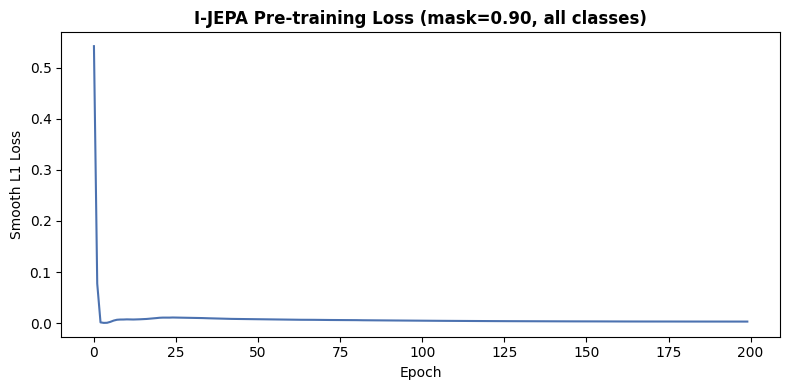

In [92]:
encoder = pretrain_ijepa(
        epochs=200,
        batch_size=512,
        lr=1e-3,
        warmup_epochs=20,
        ema_start=0.996,
        ema_end=0.999,
)

In [94]:
clf_model, clf_test_loader, clf_history = finetune_classification(
        encoder,
        epochs=100,
        batch_size=256,
        lr=1e-4,
        physics_lambda=0.05,
        unfreeze_epoch=5,
        unfreeze_last_n=12,
        mixup_alpha=0.3,
  )
plot_clf_history(clf_history)
aucs, macro_auc = evaluate_classification(clf_model, clf_test_loader)


 FINE-TUNING IX.A — CLASSIFICATION
Classification — train: 71283, val: 8910, test: 8911
  Epoch [  1/150] | Loss: 0.5209 | Val Acc: 0.4831 | Val AUC: 0.6894 | Best AUC: 0.6894
  Epoch [  5/150] | Loss: 0.5094 | Val Acc: 0.5248 | Val AUC: 0.7148 | Best AUC: 0.7148
  → Unfreezing last 12 encoder blocks
  Epoch [ 10/150] | Loss: 0.4650 | Val Acc: 0.6443 | Val AUC: 0.8091 | Best AUC: 0.8091
  Epoch [ 15/150] | Loss: 0.4251 | Val Acc: 0.7119 | Val AUC: 0.8618 | Best AUC: 0.8618
  Epoch [ 20/150] | Loss: 0.4034 | Val Acc: 0.7448 | Val AUC: 0.8979 | Best AUC: 0.8979
  Epoch [ 25/150] | Loss: 0.3830 | Val Acc: 0.7740 | Val AUC: 0.9183 | Best AUC: 0.9183
  Epoch [ 30/150] | Loss: 0.3693 | Val Acc: 0.7852 | Val AUC: 0.9313 | Best AUC: 0.9313
  Epoch [ 35/150] | Loss: 0.3555 | Val Acc: 0.8021 | Val AUC: 0.9367 | Best AUC: 0.9374
  Epoch [ 40/150] | Loss: 0.3463 | Val Acc: 0.8189 | Val AUC: 0.9442 | Best AUC: 0.9442
  Epoch [ 45/150] | Loss: 0.3386 | Val Acc: 0.8295 | Val AUC: 0.9482 | Best AUC: 

ValueError: Input contains NaN.

In [97]:
# Run this before finetune_sr — reload encoder from saved pre-training weights
encoder = ViTEncoder(img_size=64, patch_size=8, embed_dim=384, depth=12, num_heads=6)
encoder.load_state_dict(torch.load("jepa_encoder.pth"))  # pre-training weights
encoder = encoder.to(DEVICE)
encoder.eval()

# Verify it's clean now
with torch.no_grad():
    test_input = torch.randn(2, 3, 64, 64).to(DEVICE)
    test_out = encoder(test_input)
    print("Encoder output after reload:", test_out.min().item(), test_out.max().item())
    print("Any NaN:", torch.isnan(test_out).any().item())

Encoder output after reload: -2.256589889526367 3.0251572132110596
Any NaN: False


Classification — train: 71283, val: 8910, test: 8911

 EVALUATION IX.A — ROC / AUC  (8-fold TTA)


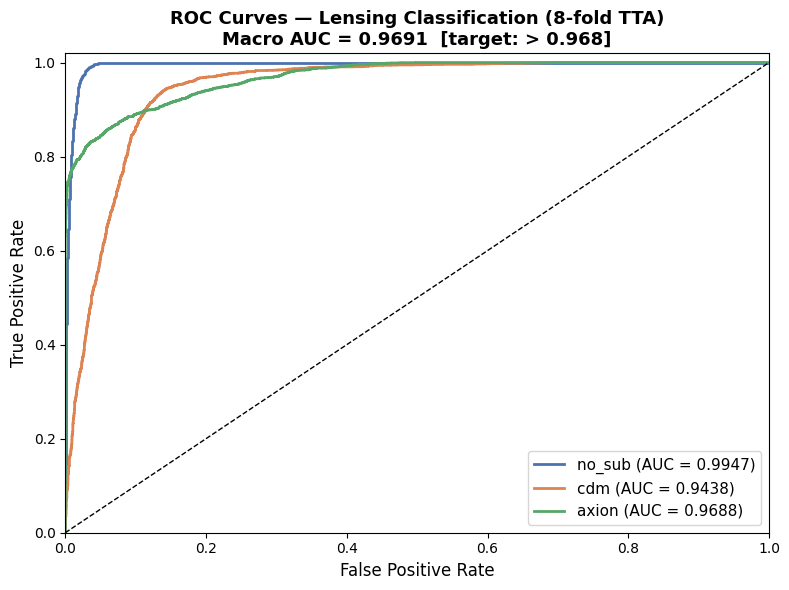


  AUC per class:
        no_sub : 0.9947
           cdm : 0.9438
         axion : 0.9688
         Macro AUC : 0.9691


In [100]:
# ── Reload classifier from best checkpoint and evaluate ──────────
encoder_clf = ViTEncoder(img_size=64, patch_size=8, embed_dim=384, depth=12, num_heads=6)
encoder_clf.load_state_dict(torch.load("jepa_encoder.pth"))
encoder_clf = encoder_clf.to(DEVICE)

clf_model = LensingClassifier(encoder_clf, embed_dim=384, num_classes=3).to(DEVICE)
clf_model.load_state_dict(torch.load("best_classifier.pth"))
clf_model.eval()

_, _, clf_test_loader = build_clf_loaders(batch_size=256)

aucs, macro_auc = evaluate_classification(clf_model, clf_test_loader)

In [98]:
sr_model, sr_test_loader, sr_history = finetune_sr(
    encoder,
    epochs=50,
    batch_size=32,
    lr=5e-5,
)
plot_sr_history(sr_history)
mse, psnr, ssim_score = evaluate_sr(sr_model, sr_test_loader)


 FINE-TUNING IX.B — SUPER RESOLUTION  (RCAN + Multi-Loss)
SR — train: 8000, val: 1000, test: 1000
SRNet params: 8.0M
  Epoch [  1/200] [Charb] | Loss: 0.0124 | PSNR: 41.5225 | SSIM: 0.9726 | Best PSNR: 41.5225
  Epoch [ 10/200] [Charb] | Loss: 0.0104 | PSNR: 42.1862 | SSIM: 0.9757 | Best PSNR: 42.1862
  Epoch [ 20/200] [Charb] | Loss: 0.0104 | PSNR: 42.2064 | SSIM: 0.9758 | Best PSNR: 42.2064
  Epoch [ 30/200] [Charb] | Loss: 0.0104 | PSNR: 42.2099 | SSIM: 0.9758 | Best PSNR: 42.2106
  Epoch [ 40/200] [Charb+SSIM] | Loss: 0.0983 | PSNR: 37.7245 | SSIM: 0.8676 | Best PSNR: 42.2106
  Epoch [ 50/200] [Charb+SSIM] | Loss: 0.0965 | PSNR: 38.0484 | SSIM: 0.8796 | Best PSNR: 42.2106
  Epoch [ 60/200] [Charb+SSIM] | Loss: 0.0976 | PSNR: 38.0622 | SSIM: 0.8812 | Best PSNR: 42.2106
  Epoch [ 70/200] [Charb+SSIM] | Loss: 0.0942 | PSNR: 38.0628 | SSIM: 0.8820 | Best PSNR: 42.2106


KeyboardInterrupt: 

SR — train: 8000, val: 1000, test: 1000

 EVALUATION IX.B — MSE / PSNR / SSIM

  Metric            Model      Bicubic      Delta
  ------------------------------------------------
  MSE            0.000061     0.000085  -0.000024
  PSNR (dB)       42.2072      40.7358    +1.4714
  SSIM             0.9758       0.9589    +0.0169


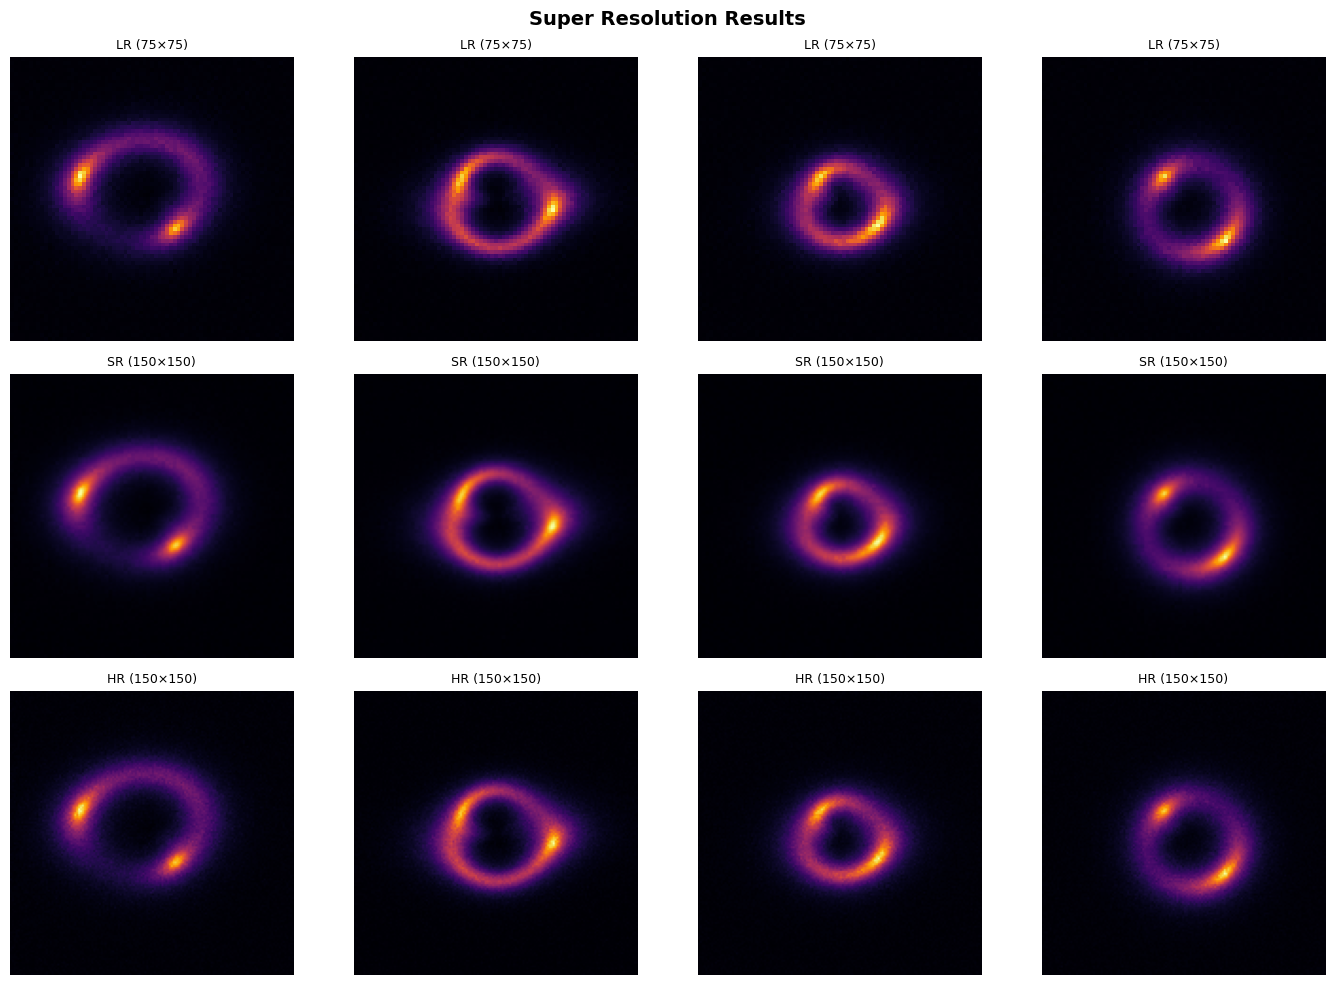

In [101]:
# ── Reload SR model and evaluate ─────────────────────────────────
sr_model = SRNet(n_feat=64, n_groups=10, n_rcab=10, scale=2).to(DEVICE)
sr_model.load_state_dict(torch.load("best_sr_model.pth"))
sr_model.eval()

_, _, sr_test_loader = build_sr_loaders(batch_size=32)

mse, psnr, ssim_score = evaluate_sr(sr_model, sr_test_loader)

In [102]:
# ── Final summary ─────────────────────────────────────────────────
print("\n" + "="*60)
print("  FINAL RESULTS SUMMARY")
print("="*60)
print(f"\n  IX.A Classification:")
for cls, a in zip(CLF_CLASSES, aucs):
    print(f"    {cls:>10s} AUC : {a:.4f}")
print(f"    {'Macro':>10s} AUC : {macro_auc:.4f}  (target: > 0.968)")
print(f"\n  IX.B Super Resolution:")
print(f"    MSE  : {mse:.6f}  (baseline: 0.000085)")
print(f"    PSNR : {psnr:.4f} dB  (baseline: 40.7358)")
print(f"    SSIM : {ssim_score:.4f}  (target: > 0.961)")


  FINAL RESULTS SUMMARY

  IX.A Classification:
        no_sub AUC : 0.9947
           cdm AUC : 0.9438
         axion AUC : 0.9688
         Macro AUC : 0.9691  (target: > 0.968)

  IX.B Super Resolution:
    MSE  : 0.000061  (baseline: 0.000085)
    PSNR : 42.2072 dB  (baseline: 40.7358)
    SSIM : 0.9758  (target: > 0.961)
